In [1]:
import pandas as pd
import datetime as dt
import pathlib

from neuralforecast import NeuralForecast
from statsforecast import StatsForecast
import matplotlib.pyplot as plt

In [5]:
def to_datetime(input_string):
    return dt.datetime.strptime(input_string, "%Y-%m-%d %H:%M:%S").replace(minute=0, second=0)

def connect_gt_and_pred(df_gt, df_pred):
    Y_df_2 = df_gt.set_index('ds')

    cv_df_2 = df_pred.reset_index()
    cutoff_stamps = []
    if 'cutoff' not in cv_df_2.columns:
        for i in range(len(cv_df_2)):
            hours_to_subtract = i%3 + 1
            cutoff_stamp = cv_df_2.at[i, 'ds'] - dt.timedelta(hours=hours_to_subtract, minutes=0)
            cutoff_stamps.append(cutoff_stamp)
        
        cv_df_2['cutoff'] = cutoff_stamps

    cv_df_output = pd.DataFrame()
    added_rows = 0
    for i in range(len(cv_df_2)):
        if i % 3 == 0:
            cv_df_output = pd.concat([cv_df_output, cv_df_2.iloc[i].to_frame().transpose(), cv_df_2.iloc[i:i + 3]], axis=0)
            cv_df_output.reset_index(drop=True, inplace=True)
            cv_df_output.at[i+added_rows, 'ds'] = cv_df_output.at[i+added_rows, 'cutoff']
            cutoff_timestamp = cv_df_2.iloc[i]['cutoff']
            unique_id = cv_df_2.iloc[i]['unique_id']
            
            while True:
                try:
                    gt_row = Y_df_2.loc[cutoff_timestamp]
                    break
                except:
                    cutoff_timestamp = cutoff_timestamp - dt.timedelta(hours=1, minutes=0)
                    
            if type(gt_row) == type(pd.DataFrame()):
                for j, row in enumerate(Y_df_2.loc[cutoff_timestamp].iterrows()):
                    if row[1]['unique_id'] == unique_id:
                        bg_gt = row[1]['y']
                        break
        
            else:
                bg_gt = Y_df_2.loc[cutoff_timestamp]['y']

            for col in cv_df_output.columns:
                if col not in ['unique_id', 'ds', 'cutoff']:
                    cv_df_output.at[i + added_rows, col] = bg_gt

            added_rows += 1

    cv_df_output.set_index('ds')

    if 'y' not in cv_df_2.columns:
        cv_df_output['y'] = cv_df_output['cutoff']
    if 'index' in cv_df_output.columns:
        cv_df_output.drop('index', axis=1, inplace=True)

    return cv_df_output

c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\pytorch_lightning\utilities\parsing.py:199: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
Seed set to 1
Seed set to 1
c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\neuralforecast\tsdataset.py:92: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.temporal = torch.tensor(temporal, dtype=torch.float)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:441: The 'predict_dataloader' does not 

Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:441: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\neuralforecast\core.py:184: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(


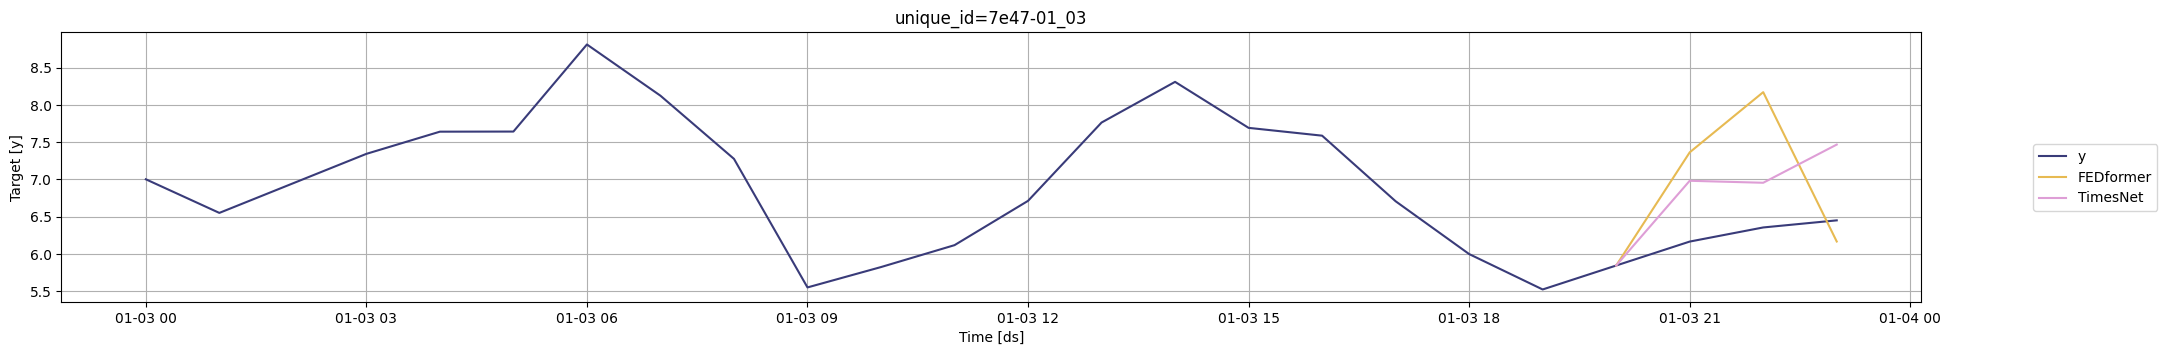

In [12]:
# read file
basepath = pathlib.Path().parent.resolve()
csv_path = pathlib.Path.joinpath(basepath, 'data/ICU_data/hourly_ICU_for_nf.csv')
Y_df = pd.read_csv(csv_path)
Y_df.drop(columns=['Unnamed: 0'], inplace=True)


# set up timestamps
timestamps = Y_df['ds']
new_timestamps = timestamps.apply(to_datetime)
Y_df['ds'] = new_timestamps
Y_df.rename(columns={'bg': 'y'}, inplace=True)

# load pretrained model
nf2 = NeuralForecast.load(path='models/ohio_train_0')


# drop last 3 y values for prediction
ids_to_drop = []
for i, row in enumerate(Y_df.iterrows()):
    if row[1]['ds'].hour>=21:
        ids_to_drop.append(i)
Y_df_shorter = Y_df.drop(ids_to_drop)

# predict
Y_hat_df_2 = nf2.predict(df=Y_df_shorter).reset_index()

# plot
df_to_plot_2 = connect_gt_and_pred(df_gt=Y_df, df_pred=Y_hat_df_2)
StatsForecast.plot(Y_df, df_to_plot_2.drop(columns=['y', 'cutoff']), max_insample_length=1260, unique_ids=['7e47-01_03'])

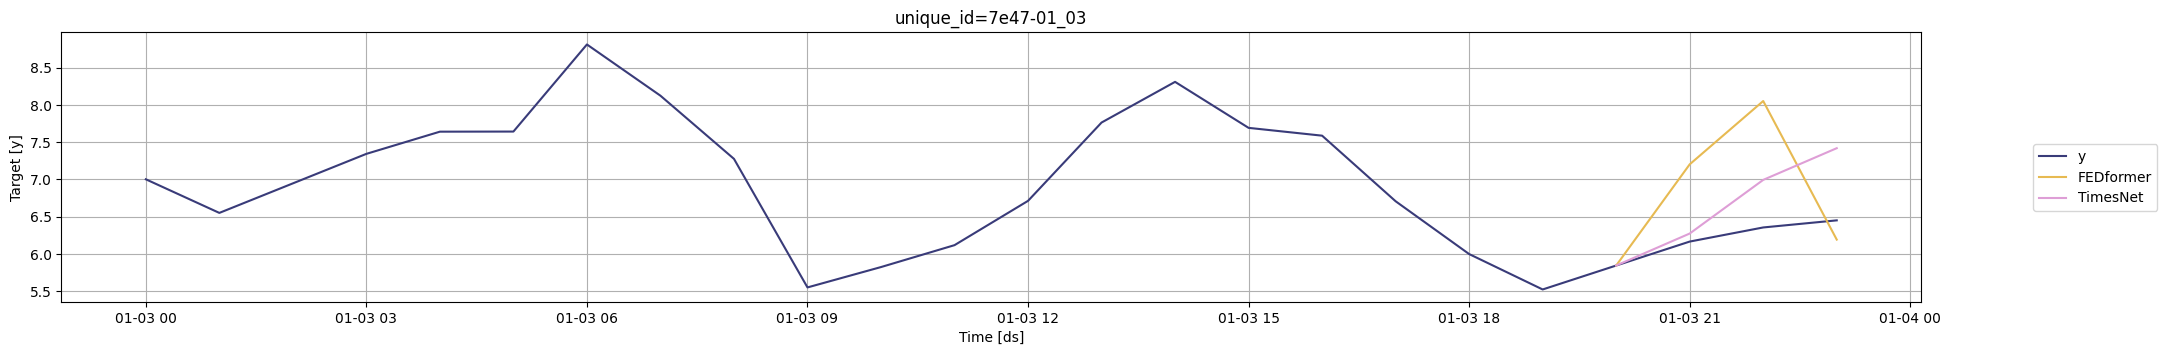

In [11]:
df_cv = nf2.cross_validation(Y_df, n_windows=1)
df_to_plot_cv = connect_gt_and_pred(Y_df, df_cv)
StatsForecast.plot(Y_df, df_to_plot_cv.drop(columns=['y', 'cutoff']), max_insample_length=1260, unique_ids=['7e47-01_03'])